# 4장 Constructing an HTML Tree

## 4.1 A Tree of Nodes

In [1]:
class Text:

  def __init__(self, text, parent):
    self.text = text
    self.children = []
    self.parent = parent

  def __repr__(self):
    return repr(self.text)


class Element:

  def __init__(self, tag, parent):
    self.tag = tag
    self.children = []
    self.parent = parent

  def __repr__(self):
    return "<" + self.tag + ">"

def print_tree(node, indent=0):
  print(" " * indent, node)
  for child in node.children:
    print_tree(child, indent + 2)

# 1. 루트 노드 (<html>) 생성
root = Element("html", parent=None)

# 2. 자식 노드 (<body>) 생성 및 연동
body = Element("body", parent=root)
root.children.append(body)

# 3. <p> 태그 생성
p = Element("p", parent=body)
body.children.append(p)

# 4. <p> 안의 텍스트와 <b> 태그 생성
text1 = Text("Hello ", parent=p)
b = Element("b", parent=p)
text2 = Text("world", parent=b)

p.children.append(text1)
p.children.append(b)
b.children.append(text2)

# 5. 완성된 트리 출력!
print_tree(root)


 <html>
   <body>
     <p>
       'Hello '
       <b>
         'world'


In [2]:
class HTMLParser:

  def __init__(self, body):
    self.body = body
    self.unfinished = []  # 트리 구축을 위한 열린 태그 스택 (3단계에서 사용)

  def parse(self):
    text = ""
    in_tag = False

    for c in self.body:
      if c == "<":
        in_tag = True
        if text:
          self.add_text(text)
        text = ""
      elif c == ">":
        in_tag = False
        self.add_tag(text)
        text = ""
      else:
        text += c

    if not in_tag and text:
      self.add_text(text)

    return self.finish()

  def add_text(self, text):
    print(" [TEXT]:", repr(text))

  def add_tag(self, tag):
    print("[TAG]:", repr(tag))

  def finish(self):
    pass

In [3]:
html_code = "<html><body>Hello <b>world</b></body></html>"
parser = HTMLParser(html_code)
parser.parse()


[TAG]: 'html'
[TAG]: 'body'
 [TEXT]: 'Hello '
[TAG]: 'b'
 [TEXT]: 'world'
[TAG]: '/b'
[TAG]: '/body'
[TAG]: '/html'


## 4.2 Constructing the Tree

In [4]:
class HTMLParser:

  def __init__(self, body):
    self.body = body
    self.unfinished = []

  def parse(self):
    text = ""
    in_tag = False
    for c in self.body:
      if c == "<":
        in_tag = True
        if text:
          self.add_text(text)
        text = ""
      elif c == ">":
        in_tag = False
        self.add_tag(text)
        text = ""
      else:
        text += c
    if not in_tag and text:
      self.add_text(text)
    return self.finish()

  def add_text(self, text):
    parent = self.unfinished[-1]
    node = Text(text, parent)
    parent.children.append(node)

  def add_tag(self, tag):
    if tag.startswith("/"):
      if len(self.unfinished) == 1:
        return
      node = self.unfinished.pop()
      parent = self.unfinished[-1]
      parent.children.append(node)
    else:
      parent = self.unfinished[-1] if self.unfinished else None
      node = Element(tag, parent)
      self.unfinished.append(node)

  def finish(self):
    while len(self.unfinished) > 1:
      node = self.unfinished.pop()
      parent = self.unfinished[-1]
      parent.children.append(node)
    return self.unfinished.pop()


In [5]:
body = "<html><body>Hello <b>world</b></body></html>"
nodes = HTMLParser(body).parse()
print_tree(nodes)


 <html>
   <body>
     'Hello '
     <b>
       'world'


## 4.3 Debugging a Parser

In [6]:
class HTMLParser:

  def __init__(self, body):
    self.body = body
    self.unfinished = []

  def parse(self):
    text = ""
    in_tag = False
    for c in self.body:
      if c == "<":
        in_tag = True
        if text:
          self.add_text(text)
        text = ""
      elif c == ">":
        in_tag = False
        self.add_tag(text)
        text = ""
      else:
        text += c
    if not in_tag and text:
      self.add_text(text)
    return self.finish()

  def add_text(self, text):
    if text.isspace():
      return  # [4.3 추가] 공백 텍스트 무시
    parent = self.unfinished[-1]
    node = Text(text, parent)
    parent.children.append(node)

  def add_tag(self, tag):
    if tag.startswith("!"):
      return  # [4.3 추가] doctype 및 주석 무시
    if tag.startswith("/"):
      if len(self.unfinished) == 1:
        return
      node = self.unfinished.pop()
      parent = self.unfinished[-1]
      parent.children.append(node)
    else:
      parent = self.unfinished[-1] if self.unfinished else None
      node = Element(tag, parent)
      self.unfinished.append(node)

  def finish(self):
    while len(self.unfinished) > 1:
      node = self.unfinished.pop()
      parent = self.unfinished[-1]
      parent.children.append(node)
    return self.unfinished.pop()


In [7]:
# 4.3장의 예외 상황(doctype, 주석, 줄바꿈/공백)이 포함된 HTML 문서
test_html = """<!doctype html>
<!-- 이것은 무시되어야 하는 주석입니다 -->
<html>
  <head>
    <!-- 헤더 내부 주석 -->
  </head>
  <body>
    <h1>4.3 파서 테스트</h1>
    <p>공백과 doctype, 주석이 잘 무시되는지 확인합니다.</p>
  </body>
</html>"""

# 파싱 및 트리 출력
nodes = HTMLParser(test_html).parse()
print_tree(nodes)


 <html>
   <head>
   <body>
     <h1>
       '4.3 파서 테스트'
     <p>
       '공백과 doctype, 주석이 잘 무시되는지 확인합니다.'


실제 브라우저(Chrome, Safari 등)는 HTML 코드 안의 줄바꿈과 공백(isspace())을 무시하지 않고 일부 보존합니다.

왜 우리가 만드는 미니 브라우저에서는 공백 텍스트를 무시(if text.isspace(): return)하도록 설계했을까요?

-> 우리 파서는 태그(<...)를 만나서 스택(self.unfinished)에 넣기 전까지는 스택이 완전히 빈(Empty) 상태입니다. 이 상태에서 공백 텍스트(\n)가 들어오면 self.unfinished[-1]을 참조하다가 IndexError로 프로그램이 튕기게 되기 때문입니다.

-> 이 책에서는 브라우저 엔진의 핵심 원리에 집중하기 위해 공백 노드를 과감히 스킵하도록 단순화

## 4.4 Self-closing Tags & Attributes

In [8]:
class Element:

  def __init__(self, tag, attributes, parent):
    self.tag = tag
    self.attributes = attributes  # 예: {"charset": "utf-8"}
    self.children = []
    self.parent = parent

  def __repr__(self):
    return "<" + self.tag + ">"


In [9]:
class HTMLParser:

  SELF_CLOSING_TAGS = [
      "area",
      "base",
      "br",
      "col",
      "embed",
      "hr",
      "img",
      "input",
      "link",
      "meta",
      "param",
      "source",
      "track",
      "wbr",
  ]

  def __init__(self, body):
    self.body = body
    self.unfinished = []

  def parse(self):
    text = ""
    in_tag = False
    for c in self.body:
      if c == "<":
        in_tag = True
        if text:
          self.add_text(text)
        text = ""
      elif c == ">":
        in_tag = False
        self.add_tag(text)
        text = ""
      else:
        text += c
    if not in_tag and text:
      self.add_text(text)
    return self.finish()

  def add_text(self, text):
    if text.isspace():
      return  # [4.3 추가] 공백 텍스트 무시
    parent = self.unfinished[-1]
    node = Text(text, parent)
    parent.children.append(node)

  def get_attributes(self, text):
    parts = text.split()
    tag = parts[0].casefold()  # HTML 태그 이름은 대소문자 구분이 없으므로 소문자화
    attributes = {}
    for attrpair in parts[1:]:
      if "=" in attrpair:
        key, value = attrpair.split("=", 1)
        if len(value) > 2 and value[0] in ["'", '"'] and value[-1] == value[0]:
          value = value[1:-1]  # 따옴표 제거
        attributes[key.casefold()] = value
      else:
        attributes[attrpair.casefold()] = ""
    return tag, attributes

  def add_tag(self, tag):
    tag, attributes = self.get_attributes(tag)  # 태그 이름과 속성 분리!
    if tag.startswith("!"):
      return

    if tag.startswith("/"):
      if len(self.unfinished) == 1:
        return
      node = self.unfinished.pop()
      parent = self.unfinished[-1]
      parent.children.append(node)
    elif tag in self.SELF_CLOSING_TAGS:
      # [셀프 클로징 태그]: 자식으로 붙이기만 하고 스택에는 넣지 않음!
      parent = self.unfinished[-1]
      node = Element(tag, attributes, parent)
      parent.children.append(node)
    else:
      # [일반 여는 태그]: 생성 후 스택에 추가
      parent = self.unfinished[-1] if self.unfinished else None
      node = Element(tag, attributes, parent)
      self.unfinished.append(node)

  def finish(self):
    while len(self.unfinished) > 1:
      node = self.unfinished.pop()
      parent = self.unfinished[-1]
      parent.children.append(node)
    return self.unfinished.pop()


In [10]:
html_with_attributes = """<!doctype html>
<html>
  <head>
    <meta charset="utf-8">
  </head>
  <body>
    <h1>이미지 테스트</h1>
    <img src="cat.jpg" alt="고양이">
    <p>단독 태그 다음 텍스트</p>
  </body>
</html>"""

nodes = HTMLParser(html_with_attributes).parse()
print_tree(nodes)


 <html>
   <head>
     <meta>
   <body>
     <h1>
       '이미지 테스트'
     <img>
     <p>
       '단독 태그 다음 텍스트'


## 4.5 Using the Node Tree

In [11]:
from browser.html import HTMLParser, print_tree
from browser.layout import Layout

# 1. HTMLParser로 트리 생성
nodes = HTMLParser("<html><body>Hello <b>world</b></body></html>").parse()
print("=== 1. 생성된 HTML 트리 ===")
print_tree(nodes)

# 2. Layout 클래스로 트리를 재귀 순회하여 좌표 및 display_list 생성
display_list = Layout(nodes).display_list
print("\n=== 2. 생성된 Display List (x좌표, y좌표, 단어, 폰트) ===")
for item in display_list:
  print(item)


=== 1. 생성된 HTML 트리 ===
 <html>
   <body>
     'Hello '
     <b>
       'world'

=== 2. 생성된 Display List (x좌표, y좌표, 단어, 폰트) ===
(13, 21.75, 'Hello', <tkinter.font.Font object 'font1'>)
(49, 21.75, 'world', <tkinter.font.Font object 'font2'>)


## 4.6 Handling Author Errors

In [12]:
from browser.html import HTMLParser, print_tree

# <html>, <head>, <body> 태그가 전혀 없는 엉성한 HTML 문서
broken_html = "<title>테스트 페이지</title>안녕하세요 <b>반갑습니다</b>"

# 파싱 및 트리 출력
nodes = HTMLParser(broken_html).parse()
print("=== 4.6장 암묵적 태그(Implicit Tags) 보정 결과 ===")
print_tree(nodes)


=== 4.6장 암묵적 태그(Implicit Tags) 보정 결과 ===
 <html>
   <head>
     <title>
       '테스트 페이지'
   <body>
     '안녕하세요 '
     <b>
       '반갑습니다'


## 4.9 Exercise

### 4-1 Comments

In [13]:
comment_html = (
    "<html><body><h1>제목</h1><!-- <p>주석 안의 태그</p> --><p>진짜 본문</p></body></html>"
)
nodes = HTMLParser(comment_html).parse()
print_tree(nodes)


 <html>
   <body>
     <h1>
       '제목'
     <p>
       '진짜 본문'


### 4-5 Syntax Highlighting

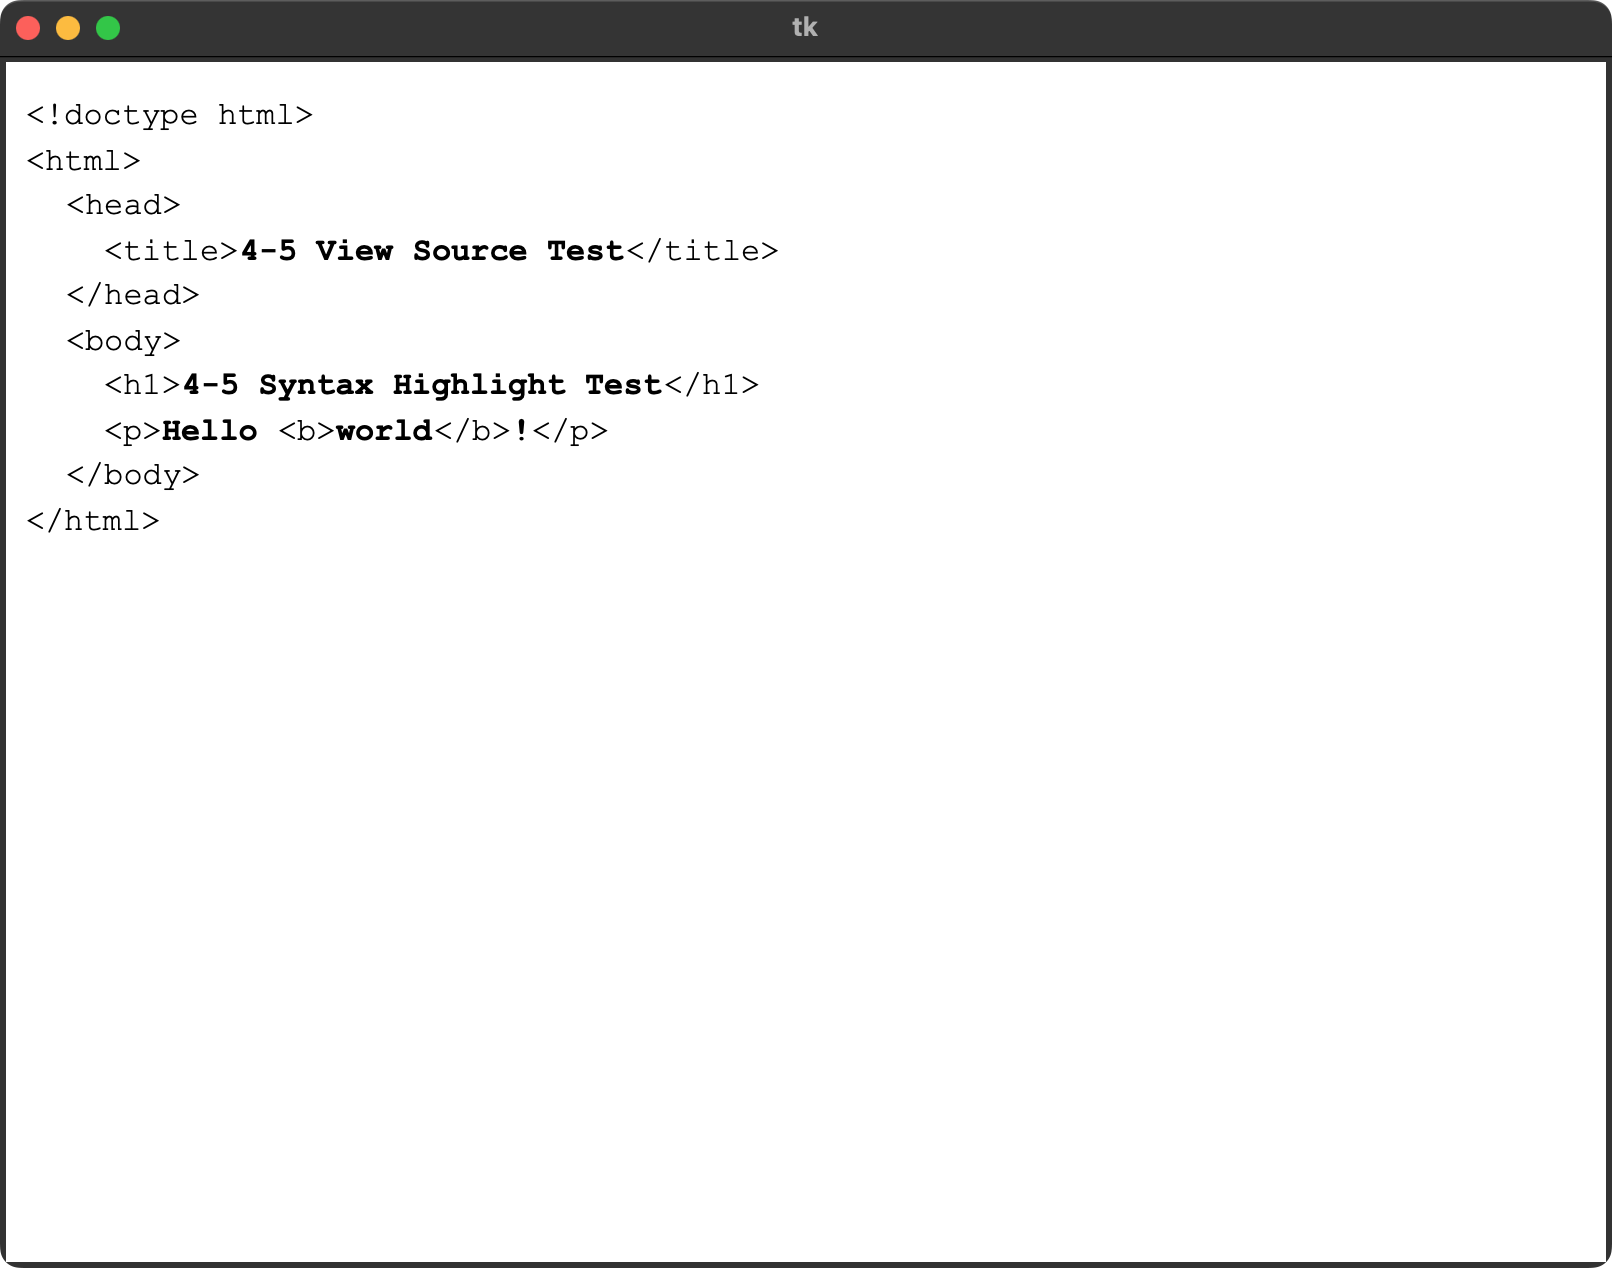

In [14]:
import importlib
import browser.browser
import browser.html
import browser.layout

from browser import Browser, URL, display_tk_window

multi_line_html = """<!doctype html>
<html>
  <head>
    <title>4-5 View Source Test</title>
  </head>
  <body>
    <h1>4-5 Syntax Highlight Test</h1>
    <p>Hello <b>world</b>!</p>
  </body>
</html>"""

browser = Browser()
url = URL(f"view-source:data:text/html,{multi_line_html}")
browser.load(url)

display_tk_window(browser.window)
